# Numeryczne rozwiązywanie równań różniczkowych zwyczajnych w Pythonie

## Opis projektu

Celem projektu jest zastosowanie metod numerycznych do rozwiązywania równań różniczkowych zwyczajnych oraz porównanie wyników z rozwiązaniami analitycznymi dla wybranych modeli matematycznych.

Projekt obejmuje:
- implementację metody Eulera,
- porównanie rozwiązania numerycznego i symbolicznego z wykorzystaniem biblioteki SymPy,
- analizę dokładności metody dla różnych kroków czasowych,
- symulację wybranych układów dynamicznych (Lotki-Volterry oraz Lorenza).

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
import sympy as sp

# Ustawienie rozmiaru wykresów
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Porównanie rozwiązania numerycznego i symbolicznego

Rozważmy równanie różniczkowe:

$$
y' = -10y
$$

z warunkiem początkowym:

$$
y(0)=1
$$

Celem jest porównanie rozwiązania uzyskanego metodą Eulera z rozwiązaniem dokładnym wyznaczonym symbolicznie.

In [6]:
# Definicja zmiennej i funkcji
t = sp.symbols('t')
y = sp.Function('y')

# Definicja równania różniczkowego
equation = sp.Eq(
    y(t).diff(t),
    -10 * y(t)
)

# Wyznaczenie rozwiązania symbolicznego
symbolic_solution = sp.dsolve(
    equation,
    ics={y(0): 1}
)

# Wyświetlenie rozwiązania
symbolic_solution

Eq(y(t), exp(-10*t))

In [7]:
# Implementacja metody Eulera
def euler_method(f, t0, y0, h, t_end):

    # Generowanie punktów czasowych
    t_values = np.arange(t0, t_end + h, h)

    # Utworzenie tablicy na rozwiązania
    y_values = np.zeros(len(t_values))

    # Ustawienie warunku początkowego
    y_values[0] = y0

    # Iteracyjne wyznaczanie kolejnych wartości
    for i in range(1, len(t_values)):
        y_values[i] = (
            y_values[i - 1]
            + h * f(
                t_values[i - 1],
                y_values[i - 1]
            )
        )

    return t_values, y_values


# Definicja równania różniczkowego
def differential_equation(t, y):
    return -10 * y

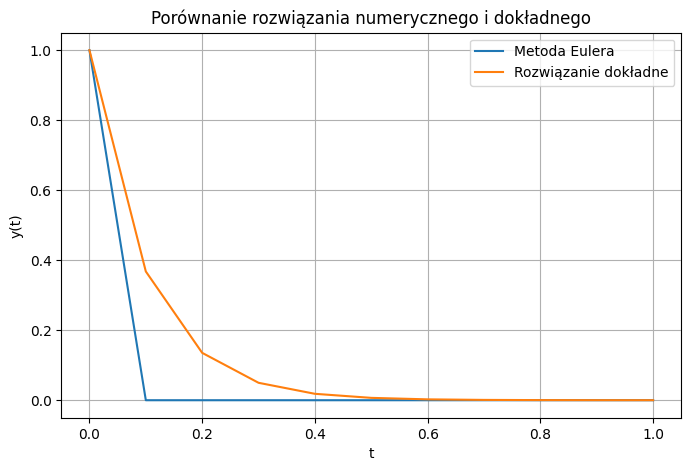

In [8]:
# Ustawienie kroku czasowego
h = 0.1

# Rozwiązanie metodą Eulera
t_num, y_num = euler_method(
    differential_equation,
    t0=0,
    y0=1,
    h=h,
    t_end=1
)

# Rozwiązanie dokładne
y_exact = np.exp(-10 * t_num)

# Tworzenie wykresu
plt.plot(
    t_num,
    y_num,
    label='Metoda Eulera'
)

plt.plot(
    t_num,
    y_exact,
    label='Rozwiązanie dokładne'
)

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title(
    'Porównanie rozwiązania numerycznego i dokładnego'
)

plt.legend()
plt.grid(True)

plt.show()

## 2. Analiza dokładności metody Eulera

Dokładność metod numerycznych zależy od wielkości kroku czasowego \( h \). W celu oceny wpływu kroku na jakość przybliżenia porównano rozwiązania uzyskane metodą Eulera dla różnych wartości \( h \).

Dla każdego przypadku obliczono maksymalny błąd bezwzględny względem rozwiązania dokładnego.

In [9]:
# Lista analizowanych kroków czasowych
step_sizes = [0.5, 0.2, 0.1, 0.05, 0.01]

# Lista na wyniki błędów
max_errors = []

# Analiza dokładności dla różnych kroków
for h in step_sizes:

    # Rozwiązanie metodą Eulera
    t_num, y_num = euler_method(
        differential_equation,
        t0=0,
        y0=1,
        h=h,
        t_end=1
    )

    # Rozwiązanie dokładne
    y_exact = np.exp(-10 * t_num)

    # Obliczenie maksymalnego błędu bezwzględnego
    error = np.max(
        np.abs(y_exact - y_num)
    )

    # Zapisanie błędu
    max_errors.append(error)

In [10]:
# Wyświetlenie wyników w formie tabeli
print("Analiza dokładności metody Eulera")
print("-" * 40)
print(f"{'Krok h':<15}{'Maksymalny błąd'}")

for h, error in zip(step_sizes, max_errors):
    print(f"{h:<15}{error:.6f}")

Analiza dokładności metody Eulera
----------------------------------------
Krok h         Maksymalny błąd
0.5            15.999955
0.2            1.135335
0.1            0.367879
0.05           0.117879
0.01           0.019201


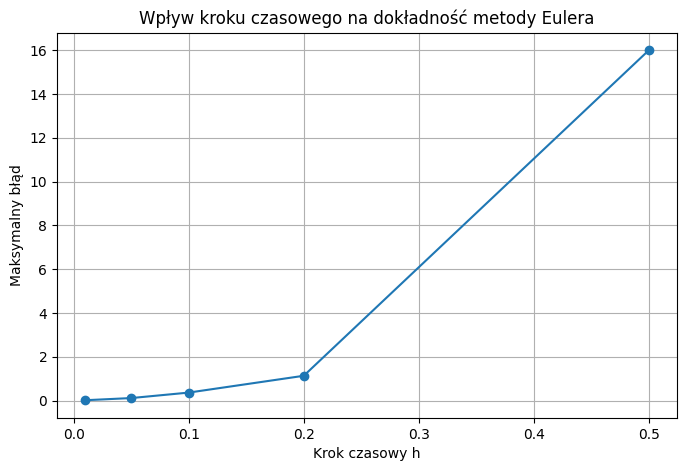

In [11]:
# Wykres zależności błędu od kroku czasowego
plt.plot(
    step_sizes,
    max_errors,
    marker='o'
)

plt.xlabel('Krok czasowy h')
plt.ylabel('Maksymalny błąd')
plt.title(
    'Wpływ kroku czasowego na dokładność metody Eulera'
)

plt.grid(True)

plt.show()

### Wnioski

Na podstawie przeprowadzonej analizy można zauważyć, że zmniejszanie kroku czasowego \( h \) prowadzi do zwiększenia dokładności rozwiązania numerycznego.

Metoda Eulera pozwala uzyskać dobre przybliżenie rozwiązania, jednak przy większych krokach czasowych obserwowane są wyraźne odchylenia od rozwiązania dokładnego.

## 3. Model Lotki–Volterry

Model Lotki–Volterry opisuje dynamikę zależności pomiędzy populacją ofiar oraz drapieżników.

Układ równań różniczkowych przyjmuje postać:

$$
\frac{dx}{dt} = \alpha x - \beta xy
$$

$$
\frac{dy}{dt} = \delta xy - \gamma y
$$

gdzie:

- $x$ — liczebność populacji ofiar,
- $y$ — liczebność populacji drapieżników,
- $\alpha$ — tempo wzrostu populacji ofiar,
- $\beta$ — współczynnik drapieżnictwa,
- $\gamma$ — tempo wymierania drapieżników,
- $\delta$ — efektywność polowania.

In [12]:
# Definicja modelu Lotki–Volterry
def lotka_volterra(t, z):

    # Rozpakowanie zmiennych
    x, y = z

    # Parametry modelu
    alpha = 1.1
    beta = 0.4
    gamma = 0.4
    delta = 0.1

    # Układ równań różniczkowych
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y

    return [dxdt, dydt]

In [13]:
# Przedział czasu symulacji
t_span = (0, 30)

# Punkty czasowe
t_eval = np.linspace(0, 30, 1000)

# Warunki początkowe
initial_conditions = [10, 5]

# Rozwiązanie układu równań
solution = solve_ivp(
    lotka_volterra,
    t_span,
    initial_conditions,
    t_eval=t_eval
)

# Pobranie wyników
time = solution.t
prey = solution.y[0]
predators = solution.y[1]

In [ ]:
# Tworzenie wykresu populacji
plt.plot(
    time,
    prey,
    label='Ofiary'
)

plt.plot(
    time,
    predators,
    label='Drapieżniki'
)

plt.xlabel('Czas')
plt.ylabel('Liczebność populacji')

plt.title(
    'Dynamika populacji w modelu Lotki–Volterry'
)

plt.legend()
plt.grid(True)

plt.show()

### Interpretacja wyników

Uzyskane wyniki pokazują cykliczne zmiany liczebności populacji ofiar i drapieżników.

Wzrost liczby ofiar prowadzi do zwiększenia populacji drapieżników, co następnie powoduje spadek liczby ofiar. Zmniejszenie liczebności ofiar skutkuje ograniczeniem liczby drapieżników, co umożliwia ponowny wzrost populacji ofiar.

Model obrazuje okresowy charakter zależności występujących w ekosystemach biologicznych.

## 4. Układ Lorenza

Układ Lorenza jest przykładem układu dynamicznego opisującego zjawiska chaotyczne. Model został opracowany w celu badania uproszczonych procesów atmosferycznych.

Układ równań Lorenza ma postać:

$$
\frac{dx}{dt} = \sigma(y-x)
$$

$$
\frac{dy}{dt} = x(\rho-z)-y
$$

$$
\frac{dz}{dt} = xy-\beta z
$$

gdzie:

- $\sigma$ — parametr związany z dyfuzją,
- $\rho$ — parametr sterujący dynamiką układu,
- $\beta$ — parametr tłumienia.

Układ Lorenza jest szczególnie interesujący ze względu na występowanie chaosu deterministycznego — niewielkie zmiany warunków początkowych mogą prowadzić do znacznych różnic w zachowaniu układu.

In [14]:
# Definicja układu Lorenza
def lorenz(t, state):

    # Rozpakowanie zmiennych
    x, y, z = state

    # Parametry modelu
    sigma = 10
    rho = 28
    beta = 8 / 3

    # Układ równań różniczkowych
    dxdt = sigma * (y - x)

    dydt = (
        x * (rho - z)
        - y
    )

    dzdt = (
        x * y
        - beta * z
    )

    return [dxdt, dydt, dzdt]

In [15]:
# Przedział czasu symulacji
t_span = (0, 40)

# Punkty czasowe
t_eval = np.linspace(0, 40, 10000)

# Warunki początkowe
initial_conditions = [1, 1, 1]

# Rozwiązanie układu Lorenza
solution = solve_ivp(
    lorenz,
    t_span,
    initial_conditions,
    t_eval=t_eval
)

# Pobranie współrzędnych
x = solution.y[0]
y = solution.y[1]
z = solution.y[2]

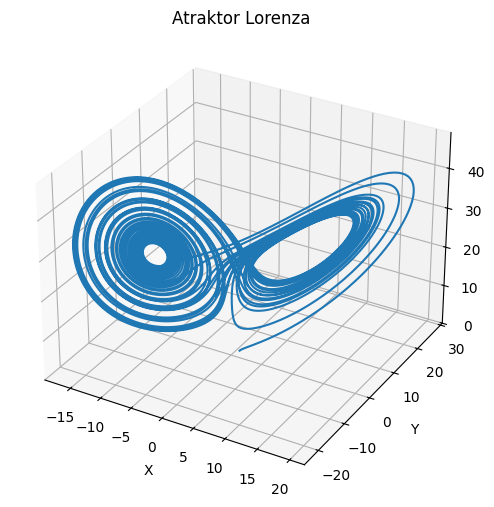

In [16]:
# Utworzenie figury 3D
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    111,
    projection='3d'
)

# Wykres trajektorii
ax.plot(x, y, z)

# Opisy osi
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Tytuł wykresu
ax.set_title(
    'Atraktor Lorenza'
)

plt.show()

### Interpretacja wyników

Uzyskany wykres przedstawia tzw. atraktor Lorenza, który jest charakterystyczny dla układów chaotycznych.

Pomimo deterministycznego charakteru równań niewielkie zmiany warunków początkowych mogą prowadzić do znaczących różnic w trajektorii układu. Zjawisko to określane jest jako chaos deterministyczny i znajduje zastosowanie między innymi w modelowaniu procesów pogodowych.

# Podsumowanie

W projekcie zastosowano metody numeryczne do rozwiązywania równań różniczkowych zwyczajnych oraz porównano rozwiązania numeryczne z rozwiązaniem symbolicznym.

Przeprowadzono analizę dokładności metody Eulera oraz wykonano symulacje wybranych układów dynamicznych, takich jak model Lotki–Volterry i układ Lorenza.
